Text(0.5, 1.0, 'stiffness=0.1, divide by dist=True')

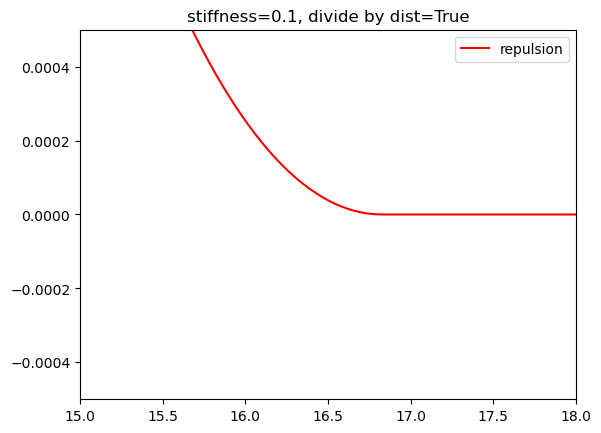

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# imagine one cell at the origin, the 2nd "r" distance from it on the x-axis (default cell radius = 8.413)
r_default = 8.413
# r_default = 5
#dvals = np.linspace(0.5, 2, 100)
dval = []
pval_repulsion = []  # potential fn
# pval_adhesion = []  # potential fn

# pval = []  # combined interaction potential fn 

r1 = r_default
r2 = r_default
rest_length = r1 + r2

# c1_repulsion = 10.0
# c2_repulsion = 10.0
m_stiffness = 10
m_stiffness = 1
m_stiffness = 0.1

# c1_relative_maximum_adhesion_distance = 1.25
# c2_relative_maximum_adhesion_distance = 1.25
# c1_adhesion = 0.4
# c2_adhesion = 0.4

# max_interactive_distance = (c1_relative_maximum_adhesion_distance * r1) + (c2_relative_maximum_adhesion_distance * r2)
# print("max_interactive_distance= ",max_interactive_distance)   # = 21.0325   (8.4 * 1.25 * 2)
# effective_adhesion = np.sqrt(c1_adhesion * c2_adhesion)
# print("effective_adhesion= ",effective_adhesion)   # = 0.4

div_d_flag = True   # in add_potentials (in core/PhysiCell_cell.cpp)

pval_min_dval = 999.0
pval_abs_min = 999.0

# m_stiffness = 10.0

for d in np.arange(0.1, 25, 0.02):   # d=distance between 2 imaginary cells (of radius r_default)
    dval.append(d)

    distance = d
    overlap = distance - rest_length;  # negative when cells overlap
    

    # calculate repulsion
    if overlap > 0.0:
        magnitude = 0
    else:
        # temp_r = -d
        # temp_r /= R       # -d/R
        # temp_r += 1.0     # 1 - d/R

        # -->
        # temp_r = 1.0 - d/rest_length
        # temp_r *= temp_r  # (1-d/R)^2

        # magnitude = m_stiffness * overlap * abs(overlap) / rest_length;   #  will make it negative
        magnitude = m_stiffness * overlap * overlap / rest_length;
    
    # effective_repulsion = np.sqrt(c1_repulsion * c2_repulsion)
    # temp_r *= effective_repulsion

    if div_d_flag:
        pval_repulsion.append(magnitude/d)
    else:
        pval_repulsion.append(magnitude)

    # calculate adhesion 
    # if d < max_interactive_distance:
    #     temp_a = -d
    #     temp_a /= max_interactive_distance  # -d/S
    #     temp_a += 1.0    # 1 - d/S
    #     temp_a *= temp_a    # (1-d/S)^2
    #     # effective_adhesion = np.sqrt(c1_adhesion * c2_adhesion)
    #     temp_a *= effective_adhesion
    #     # print(f'temp_r= {temp_r}, temp_a= {temp_a} --> temp_r - temp_a = {temp_r - temp_a}')
    #     temp_r -= temp_a
    # else:
    #     temp_a = 0.0

    # if div_d_flag:
    #     pval_adhesion.append(temp_a/d)
    # else:
    #     pval_adhesion.append(temp_a)

    if div_d_flag:
        magnitude /= d
    # pval.append(temp_r)

    	# //	velocity[i] += displacement[i] * temp_r; 
    	# axpy( &velocity , temp_r , displacement );    # core/PhysiCell_cell.cpp

    # at what distance is the potential ~= 0.0?
    if (distance < rest_length) and abs(magnitude) < 1e-4:
        # print(f'{d} -> {temp_r}')
        if abs(magnitude) < pval_abs_min:
            pval_abs_min = abs(magnitude)
            pval_min_dval = d

# print("pval_min_dval = ",pval_min_dval)
# plt.plot(dval,pval_adhesion,'g',label='adhesion')
plt.plot(dval,pval_repulsion,'r',label='repulsion')
# line = plt.plot(dval,pval,'b')

# plt.plot(dval, np.c_[pval_adhesion, pval_repulsion, pval], label=['adhesion', 'repulsion', 'potential fn']);
# plt.plot(dval, pval,'k--', label='potential fn');
# plt.plot(dval, pval_repulsion,'k--', label='repulsion');


plt.legend();

x0 = 15.0
x1 = 17.
x1=18
y0 = -0.005
y0 = -.0005
y1 = 0.015
y1=0.0005

plt.xlim(x0,x1)       # zoom in on ROI
plt.ylim(y0,y1)    # zoom in on ROI
# plt.ylim(-0.05, 30)   # zoomed out

l1_x0 = rest_length  # R
# plt.plot([l1_x0,l1_x0],[y0,y1],'b')
# plt.plot([max_interactive_distance,max_interactive_distance], [y0,y1],'b--')
# plt.plot([pval_min_dval,pval_min_dval], [y0,y1],'b--')
# plt.plot([x0,x1],[0,0],'y--')

plt.title(f"stiffness={m_stiffness}, divide by dist={div_d_flag}")
# if div_d_flag:
#     plt.title(f"stiffness={m_stiffness}, divide by dist={div_d_flag")
# else:
#     plt.title("Not dividing by d")

    